In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015/7/1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015/7/2
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015/7/3


# 数据预处理

In [19]:
df = df[df['is_canceled'] == 0]
df = df[df['hotel']=='City Hotel']

In [20]:
# 使用箱形图（IQR）方法剔除 adr（房价）异常值
q1 = df['lead_time'].quantile(0.25)
q3 = df['lead_time'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

before_rows = len(df)
df = df[(df['lead_time'] >= lower_bound) & (df['lead_time'] <= upper_bound)]
after_rows = len(df)

print(f"lead_time 下界: {lower_bound:.2f}, 上界: {upper_bound:.2f}")
print(f"剔除异常记录数: {before_rows - after_rows}")
print(f"清洗后记录数: {after_rows}")

lead_time 下界: -151.50, 上界: 284.50
剔除异常记录数: 1856
清洗后记录数: 44372


In [21]:
# lead_time 大于90的全部删除
df = df[df['lead_time'] <= 90]

In [22]:
room_types = df['reserved_room_type'].unique()
room_types


array(['A', 'F', 'D', 'E', 'B', 'C', 'G'], dtype=object)

In [23]:
# 使用箱形图（IQR）方法剔除 lead_time（预订提前时间）异常值
for room_type in room_types:
    q1 = df[df['reserved_room_type'] == room_type]['lead_time'].quantile(0.25)
    q3 = df[df['reserved_room_type'] == room_type]['lead_time'].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    before_rows = len(df)
    mask_room = df['reserved_room_type'] == room_type
    mask_iqr = (df['lead_time'] >= lower_bound) & (df['lead_time'] <= upper_bound)
    df = df[~mask_room | (mask_room & mask_iqr)]
    after_rows = len(df)

    print(f"房型: {room_type}")
    print(f"lead_time 下界: {lower_bound:.2f}, 上界: {upper_bound:.2f}")
    print(f"剔除异常记录数: {before_rows - after_rows}")
    print(f"清洗后记录数: {after_rows}")

房型: A
lead_time 下界: -59.50, 上界: 112.50
剔除异常记录数: 0
清洗后记录数: 30660
房型: F
lead_time 下界: -55.50, 上界: 100.50
剔除异常记录数: 0
清洗后记录数: 30660
房型: D
lead_time 下界: -64.00, 上界: 128.00
剔除异常记录数: 0
清洗后记录数: 30660
房型: E
lead_time 下界: -56.50, 上界: 107.50
剔除异常记录数: 0
清洗后记录数: 30660
房型: B
lead_time 下界: -59.50, 上界: 112.50
剔除异常记录数: 0
清洗后记录数: 30660
房型: C
lead_time 下界: -13.12, 上界: 21.88
剔除异常记录数: 1
清洗后记录数: 30659
房型: G
lead_time 下界: -44.25, 上界: 81.75
剔除异常记录数: 5
清洗后记录数: 30654


In [24]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,30654.0,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,30654.000000,25588.000000,2656.000000,30654.000000,30654.000000,30654.000000,30654.000000
mean,0.0,28.986201,2016.102173,26.628662,15.603380,0.752072,1.951132,1.783487,0.098454,0.008775,0.051315,0.031317,0.303973,0.235858,27.653392,137.175452,0.640830,105.637746,0.048020,0.720917
std,0.0,26.726127,0.705895,14.813560,8.701887,0.845979,1.360540,0.550221,0.384208,0.119896,0.220642,0.411714,2.574740,0.641509,55.741161,118.579366,5.906191,43.827348,0.215029,0.828635
min,0.0,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,5.000000,2016.000000,13.000000,8.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,40.000000,0.000000,78.500000,0.000000,0.000000
50%,0.0,20.000000,2016.000000,26.000000,15.500000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,72.000000,0.000000,98.800000,0.000000,1.000000
75%,0.0,49.000000,2017.000000,39.000000,23.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,216.000000,0.000000,130.000000,0.000000,1.000000
max,0.0,90.000000,2017.000000,53.000000,31.000000,14.000000,35.000000,4.000000,3.000000,10.000000,1.000000,13.000000,72.000000,21.000000,509.000000,497.000000,80.000000,510.000000,3.000000,5.000000


# 预订提前期探索

Text(0.5, 0, 'Lead Time (days)')

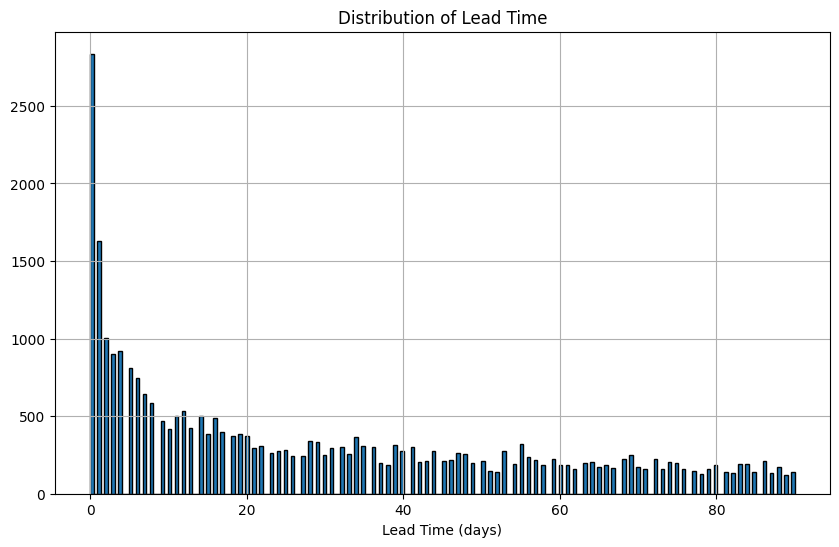

In [25]:
# Plotting the distribution of lead_time
plt.figure(figsize=(10, 6))
df['lead_time'].hist(bins=200, edgecolor='black')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')

In [26]:
df['lead_time'].quantile([0.2, 0.4, 0.6, 0.8, 0.9, 1])

0.2     3.0
0.4    13.0
0.6    31.0
0.8    56.0
0.9    72.0
1.0    90.0
Name: lead_time, dtype: float64

In [27]:
df['lead_time'].quantile([0.1, 0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

0.1     1.0
0.2     3.0
0.3     7.0
0.4    13.0
0.5    20.0
0.6    31.0
0.7    42.0
0.8    56.0
0.9    72.0
1.0    90.0
Name: lead_time, dtype: float64

# 价格探索

In [28]:
df.groupby('reserved_room_type')['adr'].aggregate(['mean', 'std', 'min', 'max','count'])

,mean,std,min,max,count
reserved_room_type,,,,,
A,96.108063,34.962076,0.0,510.00,23162
B,83.009475,38.876390,0.0,263.55,400
C,36.800000,51.973070,0.0,110.00,5
D,126.715738,41.733777,0.0,375.50,5232
E,150.541707,54.905138,0.0,451.50,785
F,184.301510,59.425197,0.0,349.63,788
G,185.798440,99.354156,0.0,372.33,282


Text(0.5, 1.0, 'Boxplot of ADR by Reserved Room Type')

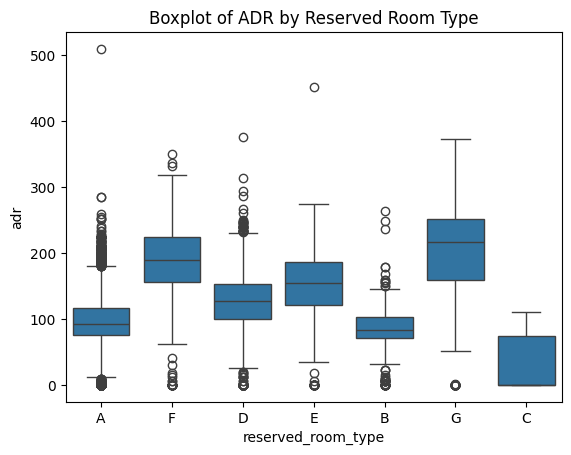

In [29]:
sns.boxplot(x='reserved_room_type', y='adr', data=df)
plt.title('Boxplot of ADR by Reserved Room Type')

# 旅行社和价格的描述

In [30]:
df['agent'].fillna(0, inplace=True)

/var/folders/9y/l07k1cmx4vl4kgw_tml08fxc0000gn/T/ipykernel_98319/2085200365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(0, inplace=True)


In [31]:
print(df.groupby('agent')['adr'].aggregate(['mean', 'std', 'min', 'max','count']).to_string())

             mean        std     min     max  count
agent                                              
0.0     86.861026  45.253005    0.00  451.50   5066
1.0     77.386065  40.705318    0.00  250.00   1192
2.0     51.222222  63.552199    0.00  144.50      9
3.0     74.699344  32.013759    0.00  145.00    183
6.0     80.517463  37.705128    0.00  174.25    410
7.0     96.502689  38.566810    0.00  307.80   2183
8.0    120.349796  49.578313    0.00  321.50    538
9.0    123.673960  38.857342    0.00  375.50  12496
10.0    95.018494  26.533792    0.00  195.70    166
11.0    72.334966  21.187426    0.00  147.71    147
12.0    92.774326  26.171078    0.00  160.00    141
13.0   104.457708  22.653075   71.40  165.00     48
14.0   127.214157  48.281742    0.00  372.33   2057
15.0    93.257383  32.545441    0.00  167.04    107
16.0    81.598242  21.756085   37.07  139.00     91
17.0    83.508571  35.005698    0.00  138.50     35
19.0    80.421053  15.849512    0.00  115.00     76
20.0    71.4